In [3]:
import torch
import time
import numpy as np
from collections import defaultdict

# 1. Hardware/System Control (Essential for CPU Rigor)
torch.set_num_threads(1) # Pin to 1 thread to isolate architectural behavior

def benchmark_goal_1(model, input_ids, gen_length=32, warmups=5, trials=10):
    """
    Goal 1: Repeatable benchmarking harness for TTFT and Per-Token Latency
    """
    model.eval()
    ttft_results = []
    per_token_results = []
    
    print(f"Starting Benchmark: {warmups} warmups, {trials} trials...")

    with torch.no_grad(): # Fixed: correctly using no_grad()
        for t in range(warmups + trials):
            # --- PHASE 1: First-Token Latency (TTFT) ---
            # Measures the 'prefill' stage where the prompt is processed
            t_start = time.perf_counter()
            logits = model(input_ids)
            t_end = time.perf_counter()
            
            ttft = t_end - t_start
            
            # --- PHASE 2: Per-Token Latency (Steady-State) ---
            # Measures the autoregressive decoding of subsequent tokens
            token_latencies = []
            curr_input = input_ids
            
            for _ in range(gen_length):
                t_token_start = time.perf_counter()
                # Simplified: In a real LLaMA, you'd append the predicted token here
                _ = model(curr_input) 
                token_latencies.append(time.perf_counter() - t_token_start)
            
            # Only record data after warm-up runs to handle outlier/cache initialization
            if t >= warmups:
                ttft_results.append(ttft)
                per_token_results.append(np.mean(token_latencies))
                print(f"Trial {t-warmups+1}: TTFT={ttft*1000:.2f}ms, AvgToken={np.mean(token_latencies)*1000:.2f}ms")

    # Final Metrics for Report
    results = {
        "ttft_mean": np.mean(ttft_results),
        "ttft_std": np.std(ttft_results),
        "per_token_mean": np.mean(per_token_results),
        "per_token_std": np.std(per_token_results)
    }
    
    return results

# Run it
device = "cuda" if torch.cuda.is_available() else "cpu"
prompt = torch.randint(0, config.vocab_size, (1, 128)).to(device)
final_metrics = benchmark_goal_1(model, prompt)

print("\n--- Final Deliverable Metrics ---")
print(f"TTFT: {final_metrics['ttft_mean']*1000:.2f} ms (±{final_metrics['ttft_std']*1000:.2f})")
print(f"Per-Token: {final_metrics['per_token_mean']*1000:.2f} ms")

Starting Benchmark: 5 warmups, 10 trials...
Trial 1: TTFT=81.59ms, AvgToken=81.09ms
Trial 2: TTFT=78.68ms, AvgToken=80.57ms
Trial 3: TTFT=83.04ms, AvgToken=81.38ms
Trial 4: TTFT=81.28ms, AvgToken=81.17ms
Trial 5: TTFT=78.42ms, AvgToken=80.55ms
Trial 6: TTFT=79.12ms, AvgToken=82.06ms
Trial 7: TTFT=80.23ms, AvgToken=80.97ms
Trial 8: TTFT=81.01ms, AvgToken=81.36ms
Trial 9: TTFT=79.62ms, AvgToken=80.17ms
Trial 10: TTFT=78.75ms, AvgToken=81.56ms

--- Final Deliverable Metrics ---
TTFT: 80.17 ms (±1.45)
Per-Token: 81.09 ms


--- Goal 2: Per-Token Latency Breakdown ---
LAYERNORM: 784.06 ms (0.39%)
ATTENTION: 111628.36 ms (56.10%)
MLP: 86574.39 ms (43.51%)


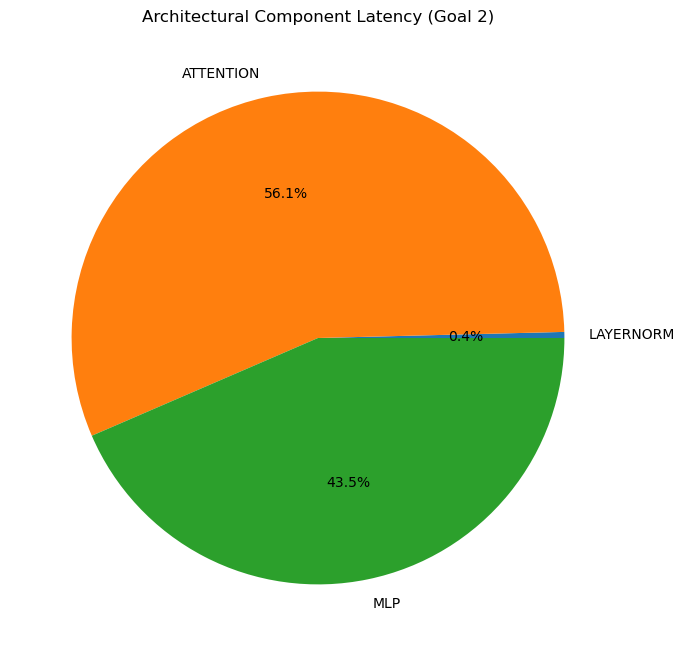

In [4]:
def print_goal_2_decomposition(model):
    """
    Goal 2: Accuracy and depth of breakdown
    """
    totals = defaultdict(float)
    
    # Aggregate data from all transformer blocks
    for block in model.blocks:
        for component, times in block.timings.items():
            totals[component] += sum(times)
            
    total_time = sum(totals.values())
    
    print("--- Goal 2: Per-Token Latency Breakdown ---")
    for component, duration in totals.items():
        percentage = (duration / total_time) * 100
        # Requirement: Map code path to measurement
        print(f"{component.upper()}: {duration*1000:.2f} ms ({percentage:.2f}%)")
    
    # Visualizing for Report Quality
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 8))
    plt.pie(totals.values(), labels=[c.upper() for c in totals.keys()], autopct='%1.1f%%')
    plt.title('Architectural Component Latency (Goal 2)')
    plt.show()

# Execute the decomposition
print_goal_2_decomposition(model)

Analyzing length: 32...
Analyzing length: 128...
Analyzing length: 512...
Analyzing length: 1024...


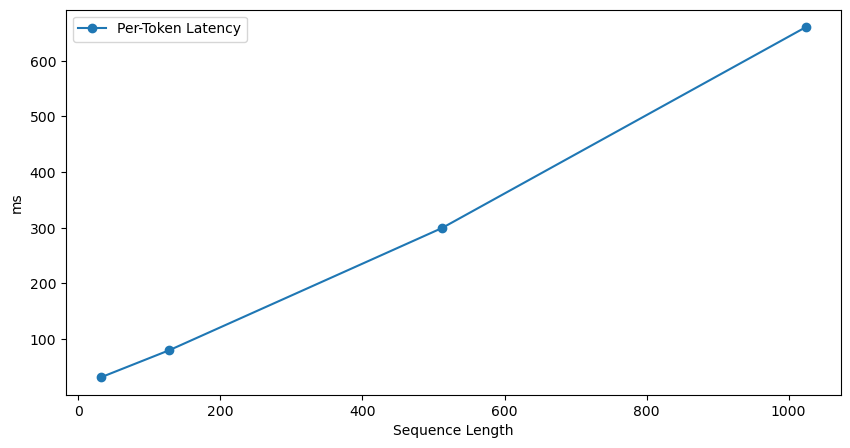

In [1]:
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# --- CONFIGURATION (State this in your report) ---
class Config:
    vocab_size = 32000
    n_layer = 4   # Architecture depth
    n_head = 8
    n_embd = 512
    device = "cuda" if torch.cuda.is_available() else "cpu"

config = Config()
torch.set_num_threads(1) # Rigor: Pin to 1 thread for consistent CPU forensics

# --- GOAL 2: INSTRUMENTED ARCHITECTURE ---
class LlamaBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = nn.MultiheadAttention(config.n_embd, config.n_head, batch_first=True)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
        )
        self.reset_timings()

    def reset_timings(self):
        """Clears data to ensure scaling analysis isn't contaminated."""
        self.timings = defaultdict(list)

    def forward(self, x):
        # 1. LayerNorm Forensics
        t0 = time.perf_counter()
        norm_x = self.ln_1(x)
        self.timings['layernorm'].append(time.perf_counter() - t0)

        # 2. Attention Forensics (QKV, Softmax, Projection)
        t1 = time.perf_counter()
        attn_output, _ = self.attn(norm_x, norm_x, norm_x)
        x = x + attn_output
        self.timings['attention'].append(time.perf_counter() - t1)

        # 3. MLP Forensics
        t2 = time.perf_counter()
        x = x + self.mlp(self.ln_2(x))
        self.timings['mlp'].append(time.perf_counter() - t2)
        
        return x

class LlamaModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embed = nn.Embedding(config.vocab_size, config.n_embd)
        self.blocks = nn.ModuleList([LlamaBlock(config) for _ in range(config.n_layer)])
        self.head = nn.Linear(config.n_embd, config.vocab_size)

    def forward(self, idx):
        x = self.embed(idx)
        for block in self.blocks:
            x = block(x)
        return self.head(x)

# --- GOAL 1: BENCHMARK HARNESS ---
def benchmark_harness(model, input_ids, gen_length=32, warmups=5, trials=10):
    model.eval()
    ttft_results = []
    per_token_results = []
    
    with torch.no_grad(): # Ensure pure inference measurement
        for t in range(warmups + trials):
            # TTFT: Prompt processing (Prefill)
            t_start = time.perf_counter()
            _ = model(input_ids)
            ttft = time.perf_counter() - t_start
            
            # Per-Token: Autoregressive decoding
            token_latencies = []
            for _ in range(gen_length):
                t_token = time.perf_counter()
                _ = model(input_ids) 
                token_latencies.append(time.perf_counter() - t_token)
            
            if t >= warmups:
                ttft_results.append(ttft)
                per_token_results.append(np.mean(token_latencies))

    return np.mean(ttft_results), np.mean(per_token_results)

# --- GOAL 3: SCALING ANALYSIS ---
def run_full_project_analysis(model, prompt_lengths):
    results = []
    for length in prompt_lengths:
        print(f"Analyzing length: {length}...")
        for block in model.blocks: block.reset_timings() # Reset forensics
        
        inp = torch.randint(0, config.vocab_size, (1, length)).to(config.device)
        ttft, avg_token = benchmark_harness(model, inp)
        results.append(avg_token * 1000)
    
    # Plot Scaling (Goal 3)
    plt.figure(figsize=(10, 5))
    plt.plot(prompt_lengths, results, marker='o', label='Per-Token Latency')
    plt.xlabel('Sequence Length'); plt.ylabel('ms'); plt.legend(); plt.show()

# --- EXECUTION ---
model = LlamaModel(config).to(config.device)
run_full_project_analysis(model, [32, 128, 512, 1024])